# Day 1 work

In [ ]:
library(Seurat)
library(ggplot2)
library(Matrix)
library(reshape2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    %||%, intersect, t



Attaching package: ‘Seurat’


The following object is masked from ‘package:base’:

    %||%




# Data loading

In [59]:
# Load the raw 10x H5 file
healthy.pbmc.data <- Read10X_h5("~/singlecell/data/5k_Human_Donor1_PBMC/filtered_feature_bc_matrix.h5")
# Create a Seurat object
healthy.pbmc <- CreateSeuratObject(healthy.pbmc.data, project = "PBMC")

ALL.pbmc.data <- Read10X_h5("~/singlecell/data/10k_5p_Human_diseased_PBMC_ALL_Fresh/10k_5p_Human_diseased_PBMC_ALL_Fresh_count_filtered_feature_bc_matrix.h5")
ALL.pbmc <- CreateSeuratObject(ALL.pbmc.data, project = "ALL_PBMC")

## Data object inspection

In [60]:
# inspect the object at a high level
healthy.pbmc

An object of class Seurat 
38606 features across 5710 samples within 1 assay 
Active assay: RNA (38606 features, 0 variable features)
 1 layer present: counts

In [61]:
# inspect the object in depth
# Make particular note of the @assays slot, which contains the raw count matrix and other matrices that we will generate later
# Investigate the layers, cells, and features of the RNA assay
str(healthy.pbmc)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. .. .. ..@ layers    :List of 1
  .. .. .. .. ..$ counts:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:19262779] 8 18 21 36 51 55 60 66 69 77 ...
  .. .. .. .. .. .. ..@ p       : int [1:5711] 0 7089 9193 12757 17128 20073 24235 26657 30348 33337 ...
  .. .. .. .. .. .. ..@ Dim     : int [1:2] 38606 5710
  .. .. .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. ..@ x       : num [1:19262779] 1 3 1 2 3 1 1 6 4 1 ...
  .. .. .. .. .. .. ..@ factors : list()
  .. .. .. ..@ cells     :Formal class 'LogMap' [package "SeuratObject"] with 1 slot
  .. .. .. .. .. ..@ .Data: logi [1:5710, 1] TRUE TRUE TRUE TRUE TRUE TRUE ...
  .. .. .. .. .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. .. .. .. .. ..$ : c

In [62]:
# what do you notice about the counts layer?
# is it what you expected to see?
# how is it similar to or different from transcriptomics data you've worked with before?

dim(healthy.pbmc@assays$RNA@layers$counts)

head(healthy.pbmc@assays$RNA@layers$counts)

[1] 38606  5710

6 x 5710 sparse Matrix of class "dgCMatrix"
                                                                              
[1,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
[2,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
[3,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
[4,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
[5,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
[6,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
                                                                              
[1,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
[2,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
[3,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
[4,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
[5,] . .

In [63]:
# what does the cells slot contain?
dim(healthy.pbmc@assays$RNA@cells)

head(healthy.pbmc@assays$RNA@cells)

[1] 5710    1

,counts
AAACCAAAGGTGACGA-1,TRUE
AAACCCTGTGACGAGT-1,TRUE
AAACGAATCAGGCTAC-1,TRUE
AAACGACAGATTGACT-1,TRUE
AAACGATGTCTTGAAC-1,TRUE
AAACGATGTGCGCGAA-1,TRUE


In [ ]:
table(healthy.pbmc@assays$RNA@cells[, 1])


TRUE 
5710 

In [64]:
# what does the features slot contain?
dim(healthy.pbmc@assays$RNA@features)

head(healthy.pbmc@assays$RNA@features)

[1] 38606     1

,counts
DDX11L2,TRUE
MIR1302-2HG,TRUE
FAM138A,TRUE
ENSG00000290826,TRUE
OR4F5,TRUE
ENSG00000238009,TRUE


In [ ]:
table(healthy.pbmc@assays$RNA@features[, 1])


 TRUE 
38606 

# Compute QC metrics

In [65]:
# Mitochondrial gene percentage
healthy.pbmc[["percent.mt"]] <- PercentageFeatureSet(healthy.pbmc, pattern = "^MT-")

# Ribosomal gene percentage (optional but informative)
healthy.pbmc[["percent.ribo"]] <- PercentageFeatureSet(healthy.pbmc, pattern = "^RPL|^RPS")

In [66]:
md <- healthy.pbmc@meta.data
md$cell <- rownames(md)
md_melt <- melt(md, id.vars = "cell", measure.vars = c("nFeature_RNA", "nCount_RNA", "percent.ribo", "percent.mt"))

In [52]:
# # ---- QC plots individual ----
# p1 <- ggplot(md, aes(x = "All cells", y = nFeature_RNA)) +
#   geom_violin(trim = FALSE) +
#   geom_boxplot(width = 0.12, outlier.size = 0.3) +
#   labs(x = "", y = "Genes per cell (nFeature_RNA)", title = "QC: nFeature_RNA")

# p2 <- ggplot(md, aes(x = "All cells", y = nCount_RNA)) +
#   geom_violin(trim = FALSE) +
#   geom_boxplot(width = 0.12, outlier.size = 0.3) +
#   labs(x = "", y = "UMIs per cell (nCount_RNA)", title = "QC: nCount_RNA")

# p3 <- ggplot(md, aes(x = "All cells", y = percent.mt)) +
#   geom_violin(trim = FALSE) +
#   geom_boxplot(width = 0.12, outlier.size = 0.3) +
#   labs(x = "", y = "Percent mitochondrial (percent.mt)", title = "QC: percent.mt")

# options(repr.plot.width = 4, repr.plot.height = 6, repr.plot.res = 200)
# p1
# p2
# p3

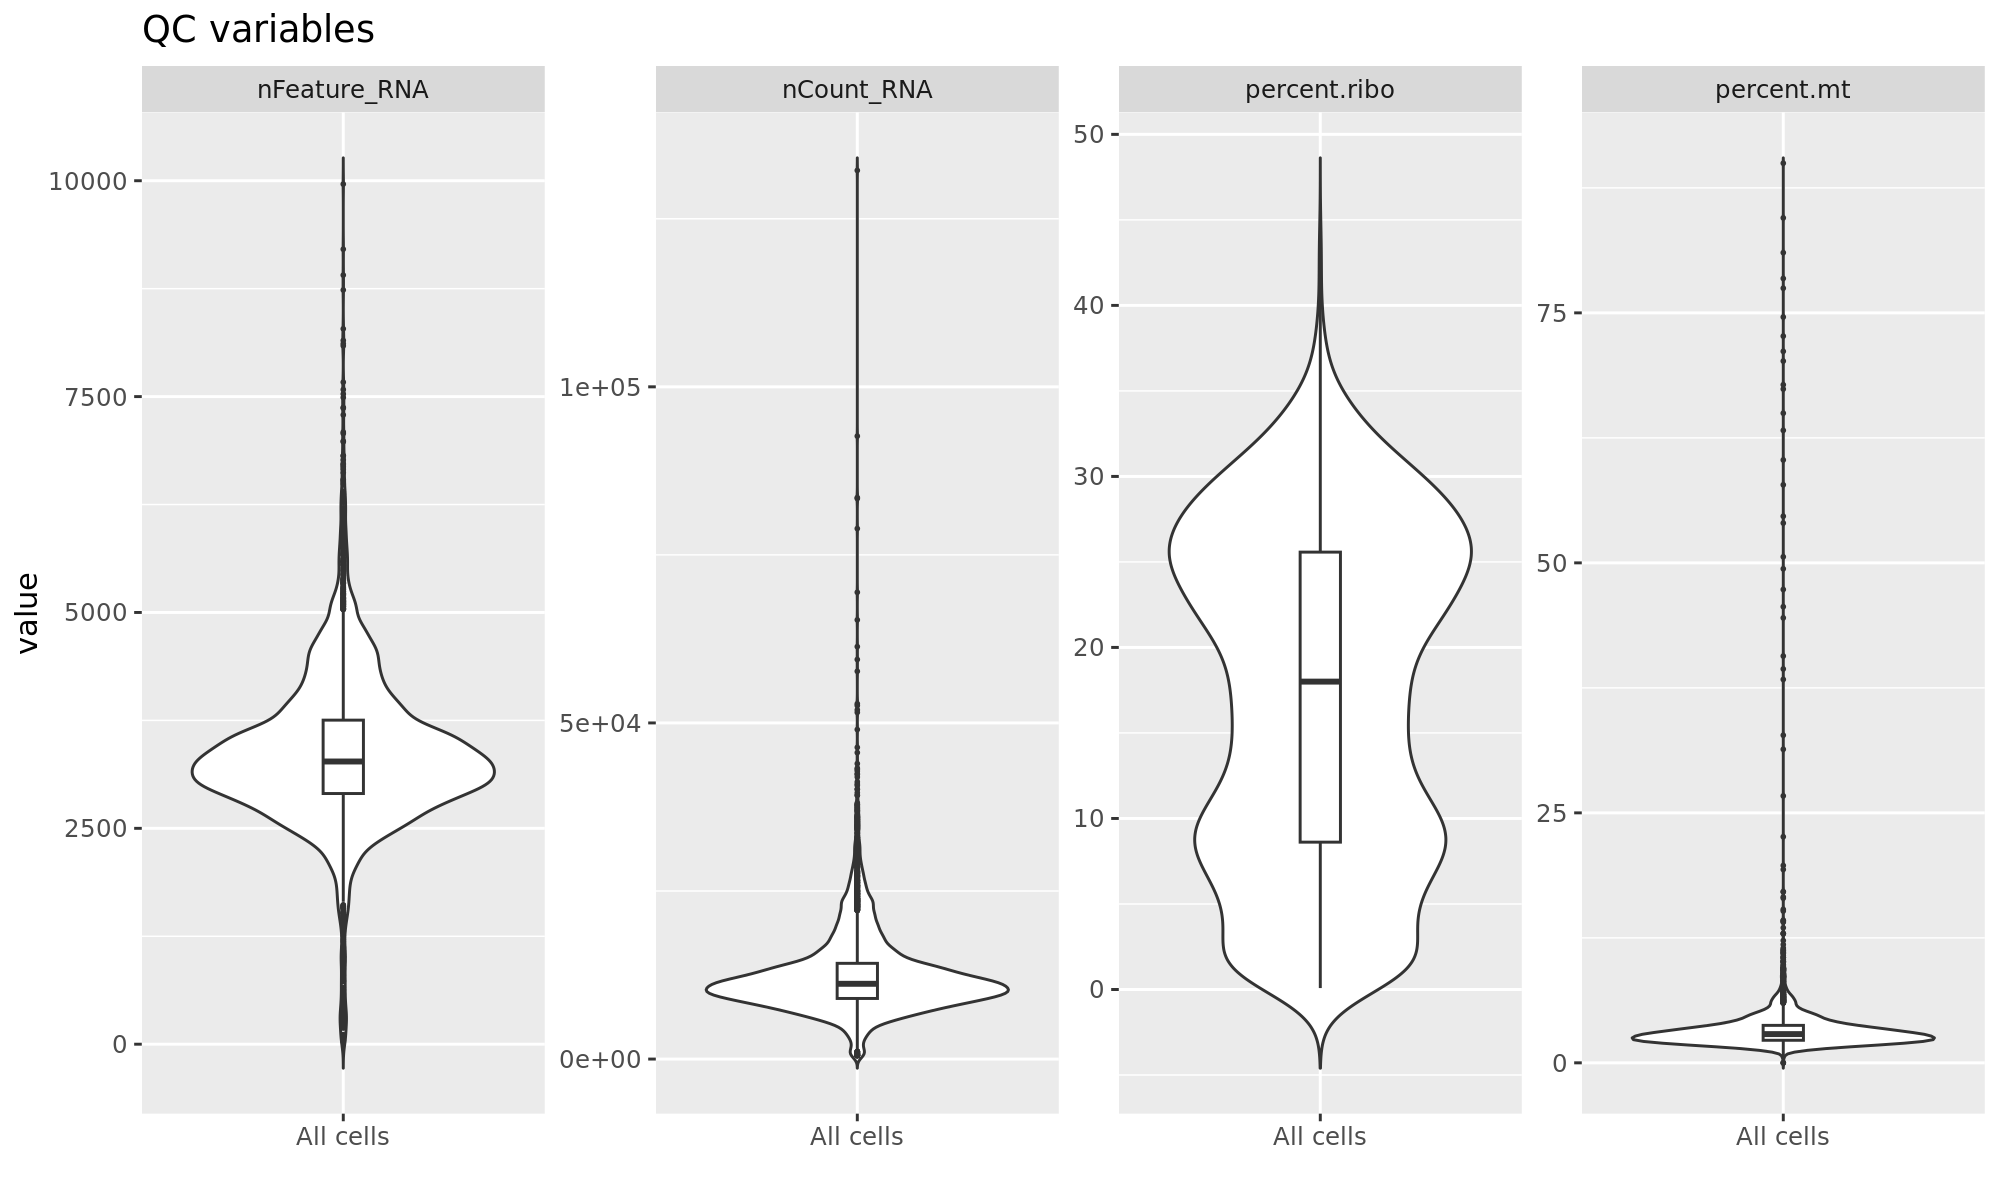

In [67]:
# # ---- QC plots combined ----
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 200)
ggplot(md_melt, aes(x = "All cells", y = value)) +
  geom_violin(trim = FALSE) +
  geom_boxplot(width = 0.12, outlier.size = 0.3) +
  labs(x = "", title = "QC variables") +
  facet_wrap(~variable, scales = "free_y", nrow = 1)

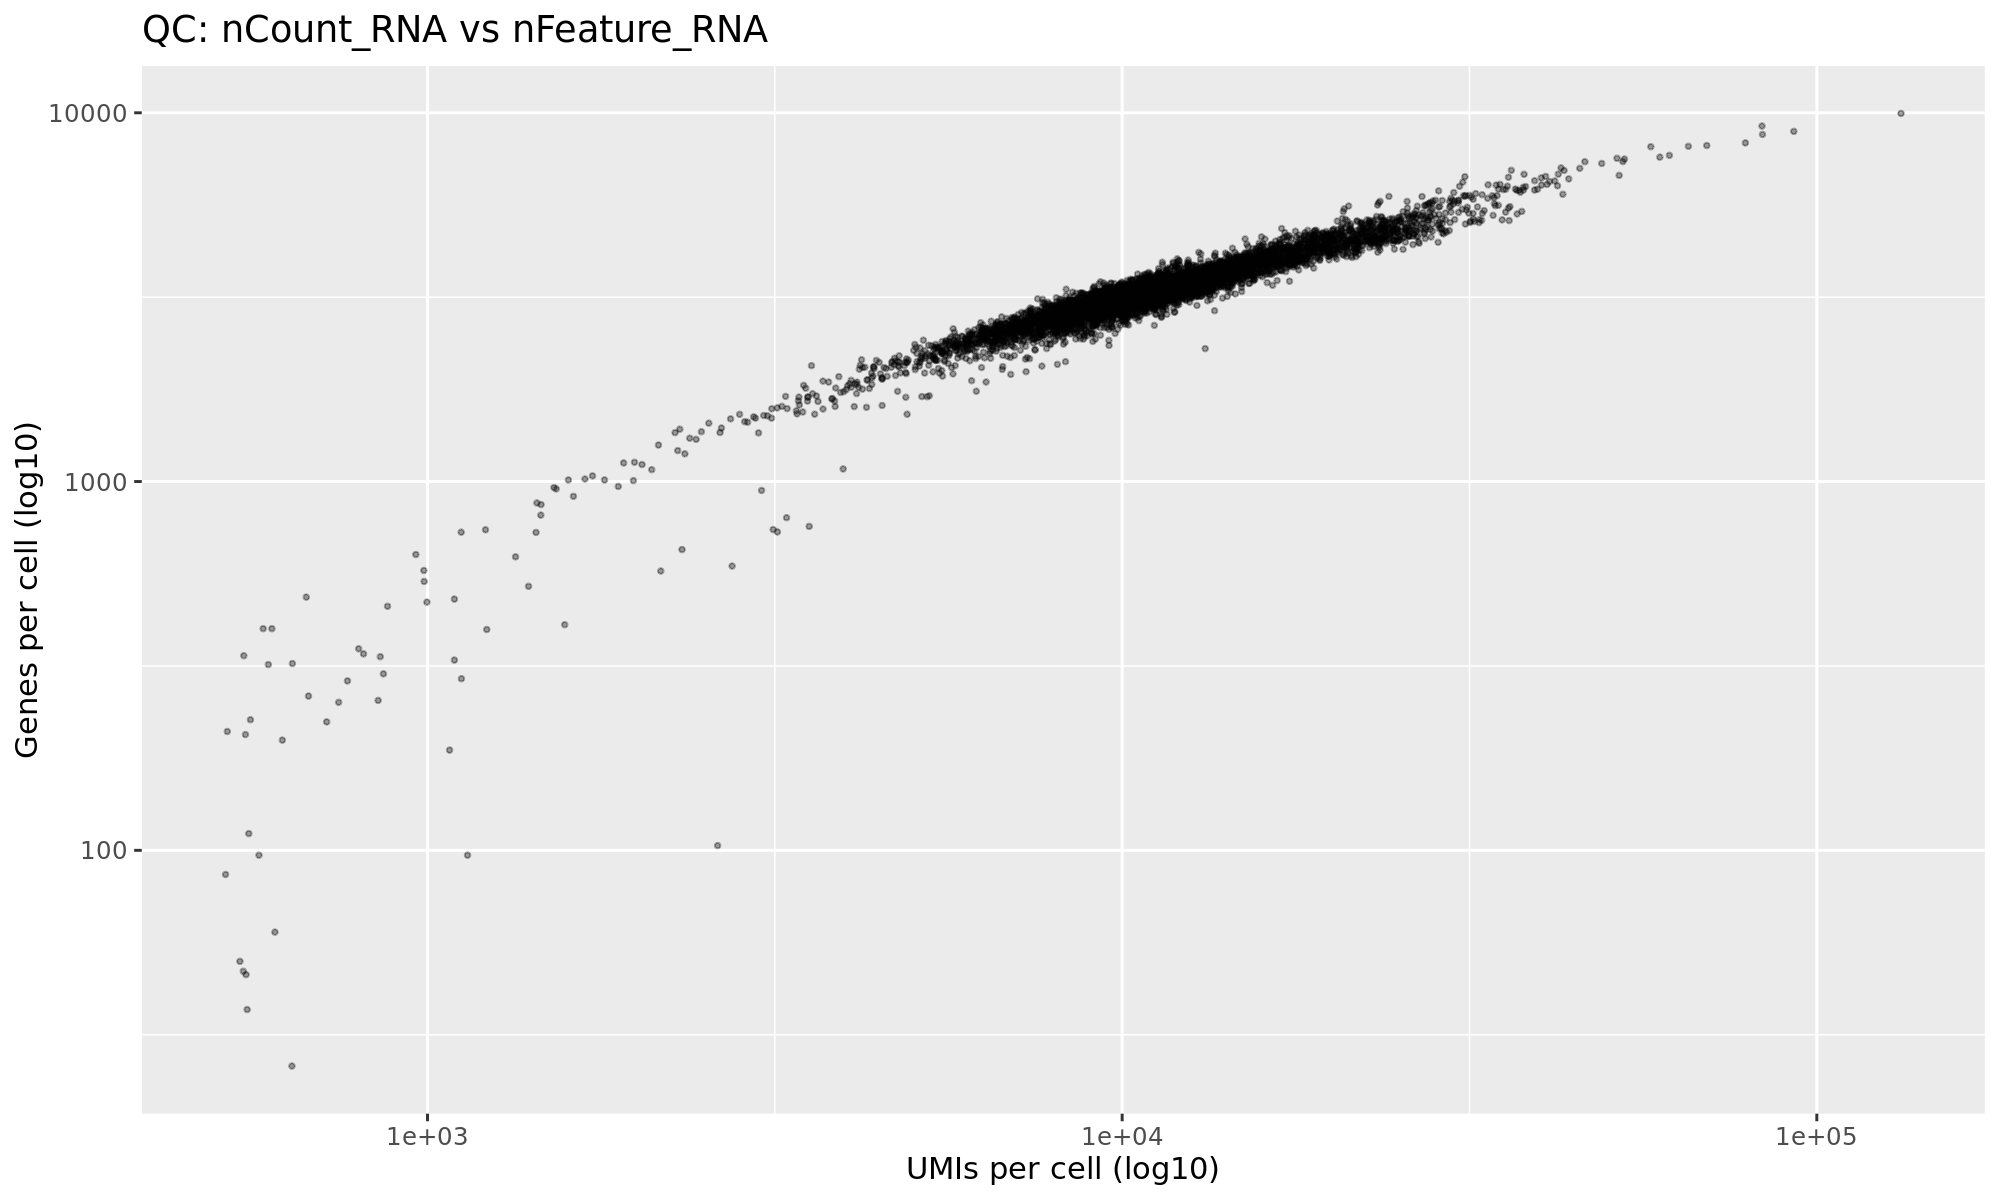

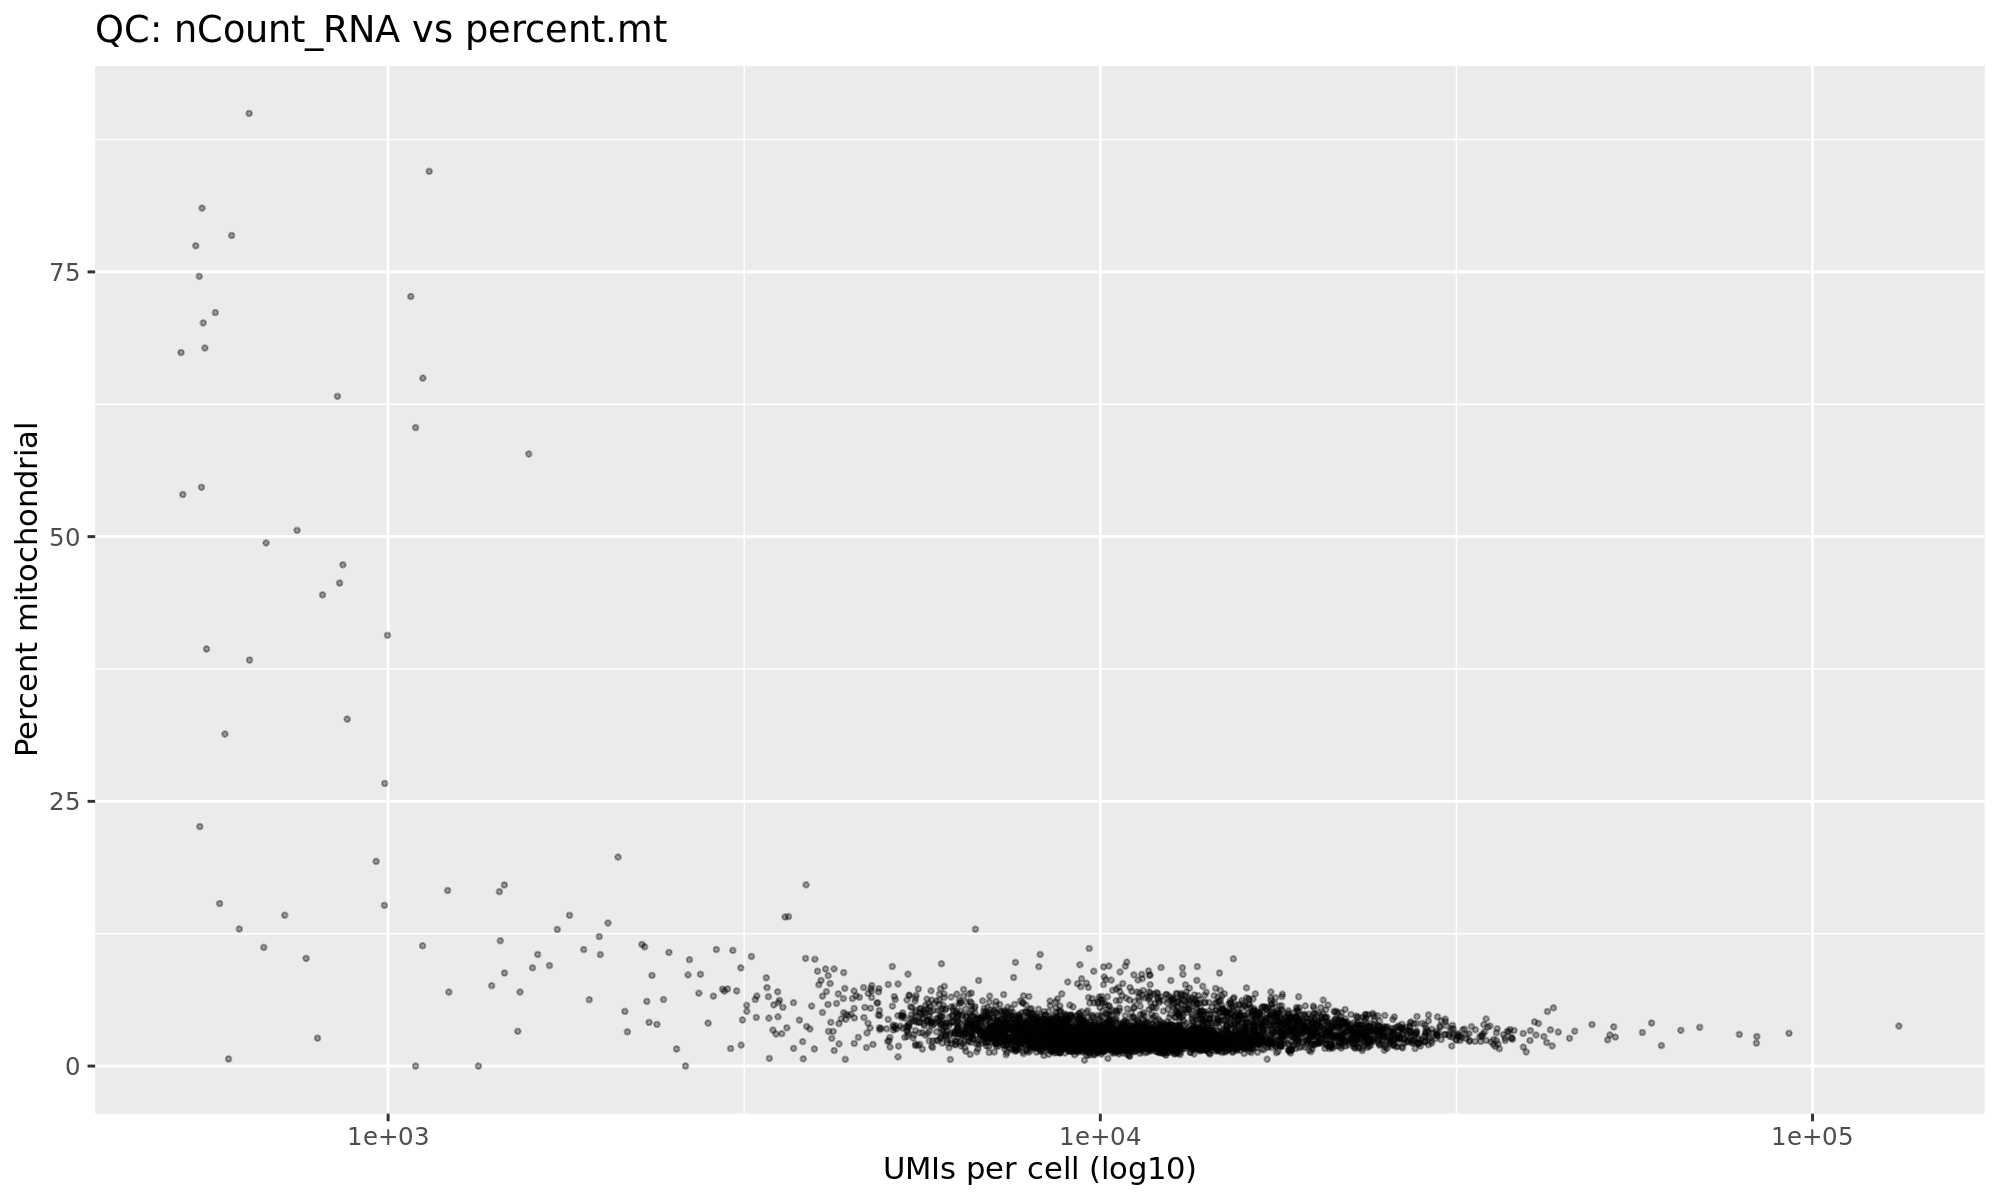

In [68]:
# options(repr.plot.width = 4, repr.plot.height = 6, repr.plot.res = 200)
p4 <- ggplot(md, aes(x = nCount_RNA, y = nFeature_RNA)) +
  geom_point(size = 0.6, alpha = 0.35) +
  scale_x_log10() + scale_y_log10() +
  labs(x = "UMIs per cell (log10)", y = "Genes per cell (log10)",
       title = "QC: nCount_RNA vs nFeature_RNA")

p5 <- ggplot(md, aes(x = nCount_RNA, y = percent.mt)) +
  geom_point(size = 0.6, alpha = 0.35) +
  scale_x_log10() +
  labs(x = "UMIs per cell (log10)", y = "Percent mitochondrial",
       title = "QC: nCount_RNA vs percent.mt")

p4
p5

# QC filtering

In [73]:
# Set thresholds
min_genes <- 200
max_genes <- 3000
max_mito  <- 10

healthy.pbmc_qc1 <- subset(
    healthy.pbmc,
    subset = nFeature_RNA > min_genes &
            nFeature_RNA < max_genes &
            percent.mt < max_mito
)

dim(healthy.pbmc_qc1)

[1] 38606  1695

In [ ]:
# What happens if we use different thresholds?
# What happens to the number of cells that pass QC? The number of features retained?
min_genes <- 100
max_genes <- 5000
max_mito  <- 20

healthy.pbmc_qc2 <- subset(
    healthy.pbmc,
    subset = nFeature_RNA > min_genes &
            nFeature_RNA < max_genes &
            percent.mt < max_mito
)

dim(healthy.pbmc_qc2)

[1] 38606  5468

In [1]:
# investigate the objects post-QC

max_gene_expr <- apply(healthy.pbmc@assays$RNA@layers$counts, 2, max)
max_gene_expr_qc1 <- apply(healthy.pbmc_qc1@assays$RNA@layers$counts, 2, max)
max_gene_expr_qc2 <- apply(healthy.pbmc_qc2@assays$RNA@layers$counts, 2, max)

ERROR: Error: object 'healthy.pbmc' not found


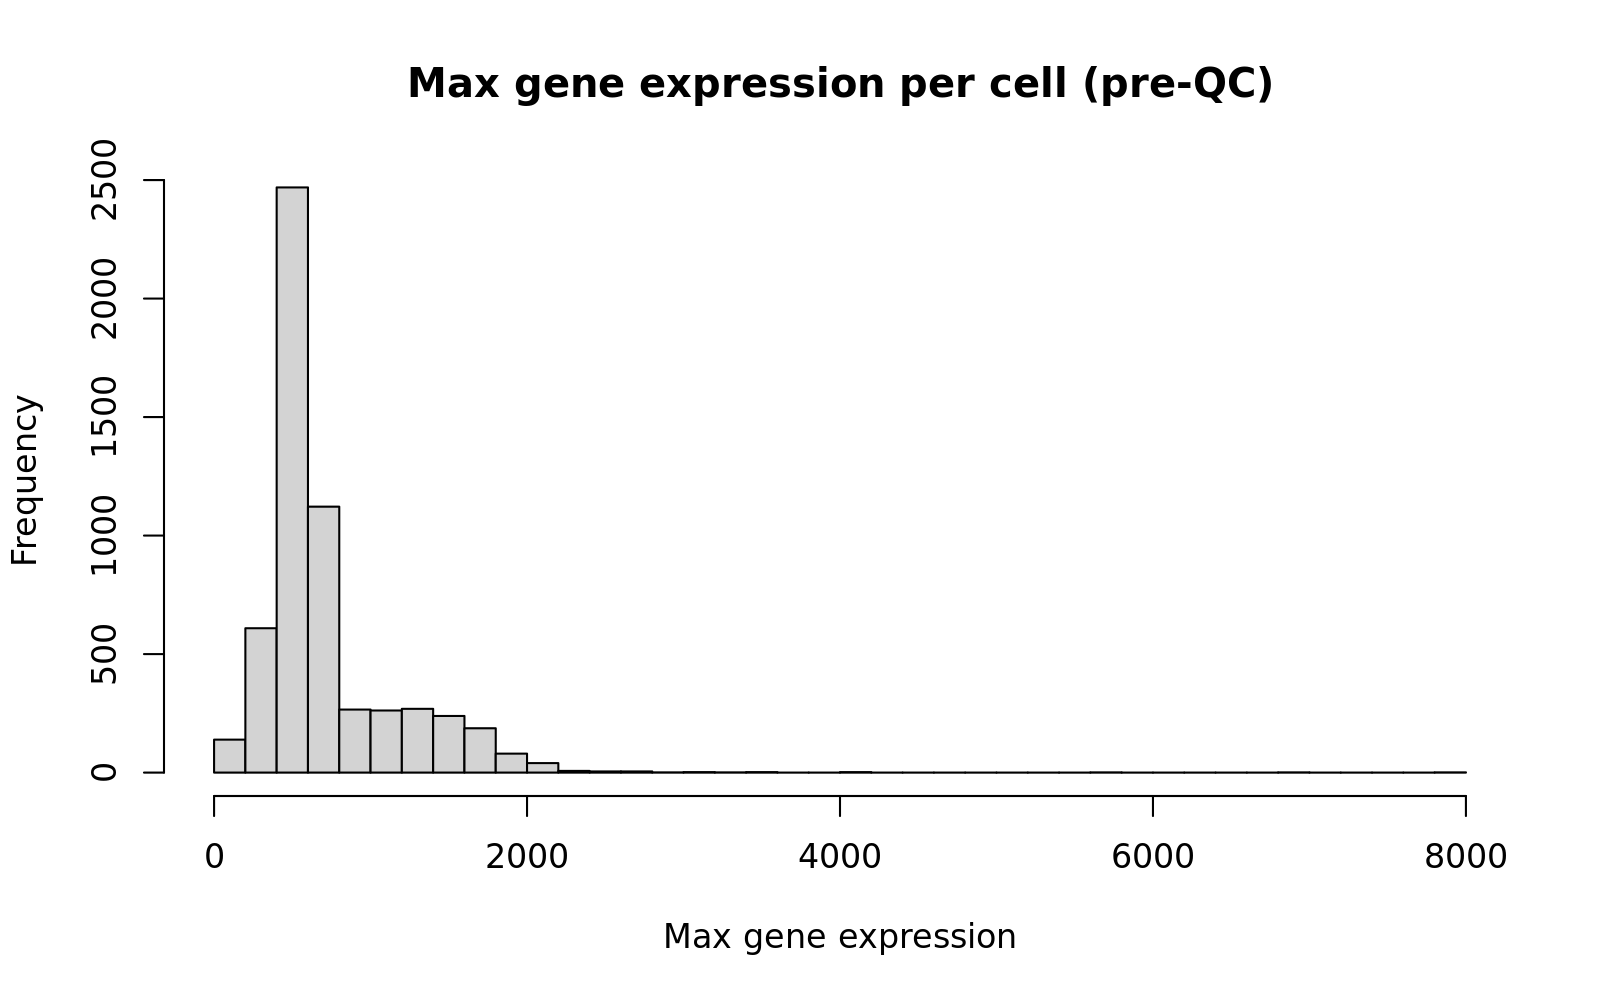

In [91]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
hist(max_gene_expr, main = "Max gene expression per cell (pre-QC)", xlab = "Max gene expression", ylab = "Frequency", breaks = 50)

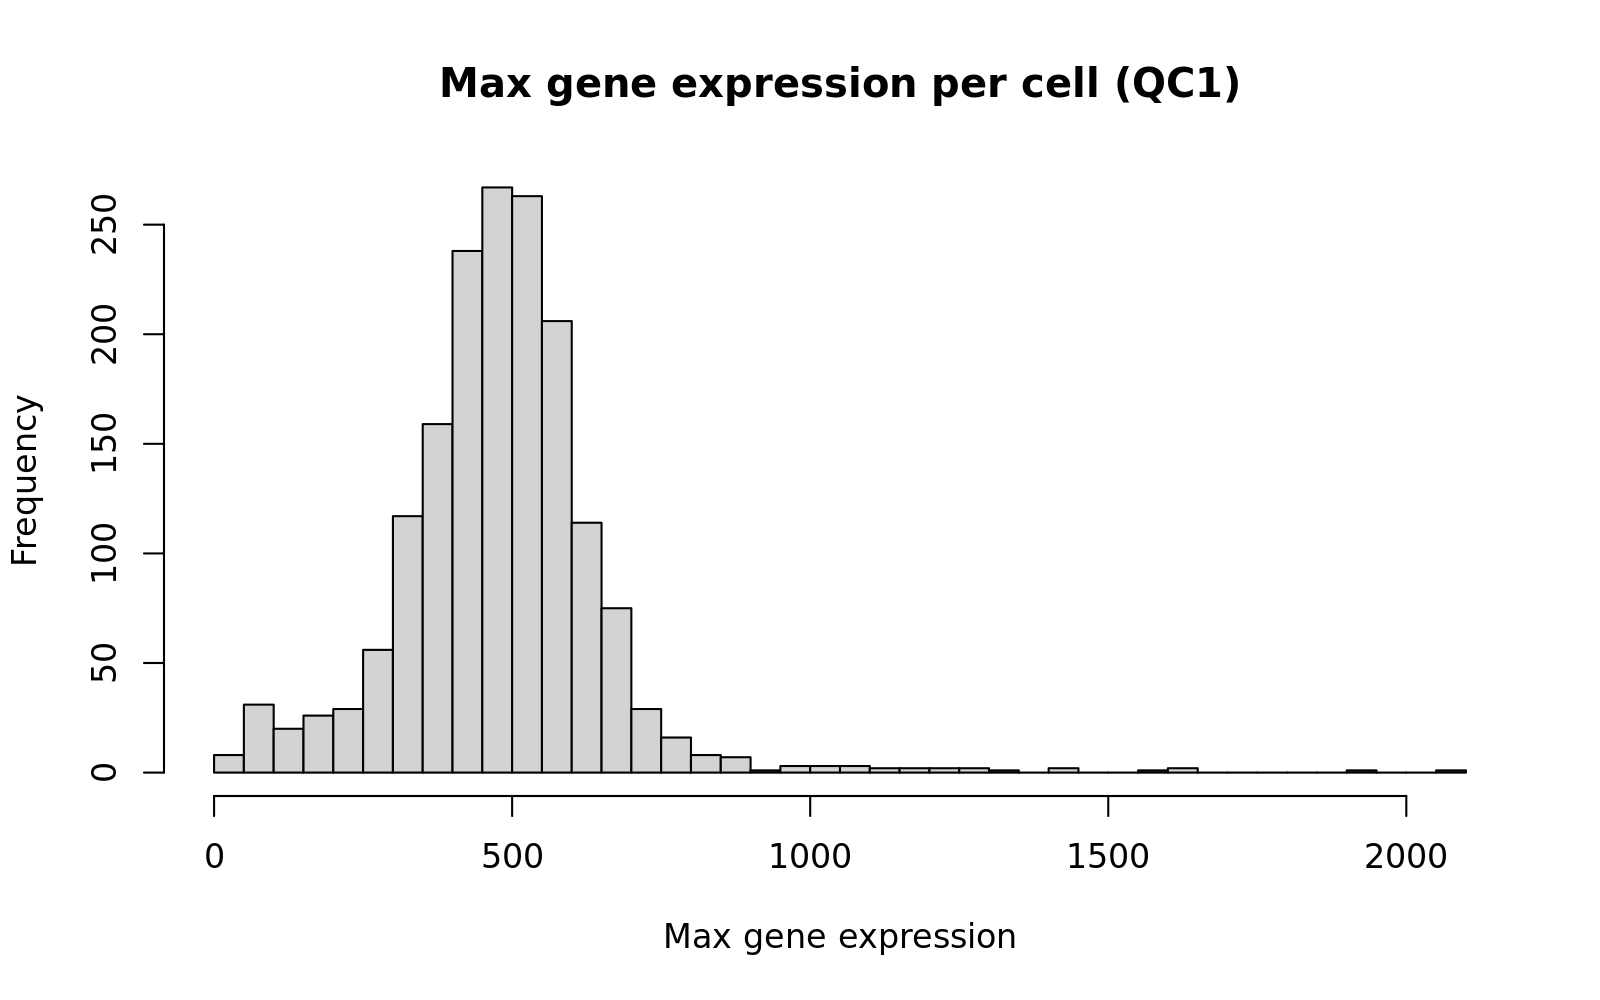

In [92]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
hist(max_gene_expr_qc1, main = "Max gene expression per cell (QC1)", xlab = "Max gene expression", ylab = "Frequency", breaks = 50)

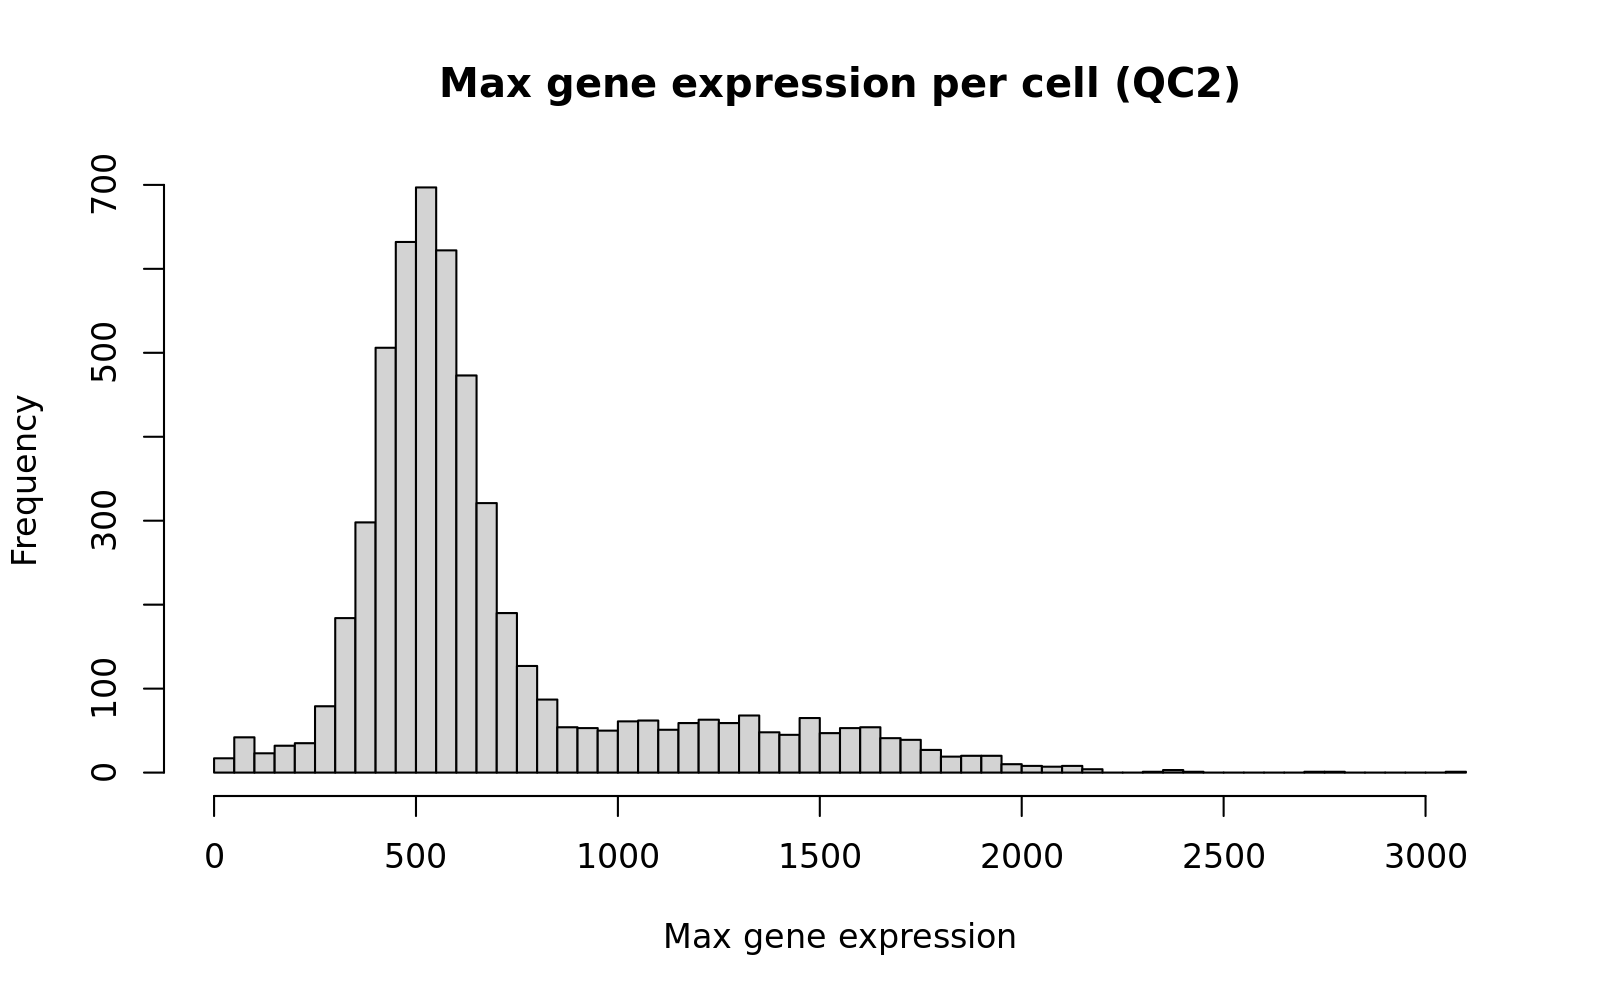

In [93]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
hist(max_gene_expr_qc2, main = "Max gene expression per cell (QC2)", xlab = "Max gene expression", ylab = "Frequency", breaks = 50)

# Feature-level distribution (gene totals)

In [102]:
# Optional: feature-level distribution (gene totals)
counts <- GetAssayData(healthy.pbmc, assay = "RNA", layer = "counts")
gene_totals <- Matrix::rowSums(counts)
gene_df <- data.frame(gene_total_umi = as.numeric(gene_totals))

p6 <- ggplot(gene_df, aes(x = gene_total_umi)) +
  geom_histogram(bins = 50, fill = 'gray65', color = 'gray25') +
  scale_x_log10() +
  labs(x = "Total UMI per gene (log10)", y = "Number of genes",
       title = "Feature-level QC: total counts per gene",
       subtitle = "Pre-QC")

counts <- GetAssayData(healthy.pbmc_qc1, assay = "RNA", layer = "counts")
gene_totals <- Matrix::rowSums(counts)
gene_df <- data.frame(gene_total_umi = as.numeric(gene_totals))

p7 <- ggplot(gene_df, aes(x = gene_total_umi)) +
  geom_histogram(bins = 50, fill = 'gray65', color = 'gray25') +
  scale_x_log10() +
  labs(x = "Total UMI per gene (log10)", y = "Number of genes",
       title = "Feature-level QC: total counts per gene",
       subtitle = "Post-QC 1")

counts <- GetAssayData(healthy.pbmc_qc2, assay = "RNA", layer = "counts")
gene_totals <- Matrix::rowSums(counts)
gene_df <- data.frame(gene_total_umi = as.numeric(gene_totals))

p8 <- ggplot(gene_df, aes(x = gene_total_umi)) +
  geom_histogram(bins = 50, fill = 'gray65', color = 'gray25') +
  scale_x_log10() +
  labs(x = "Total UMI per gene (log10)", y = "Number of genes",
       title = "Feature-level QC: total counts per gene",
       subtitle = "Post-QC 2")

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 9265 rows containing non-finite outside the scale range (`stat_bin()`).”


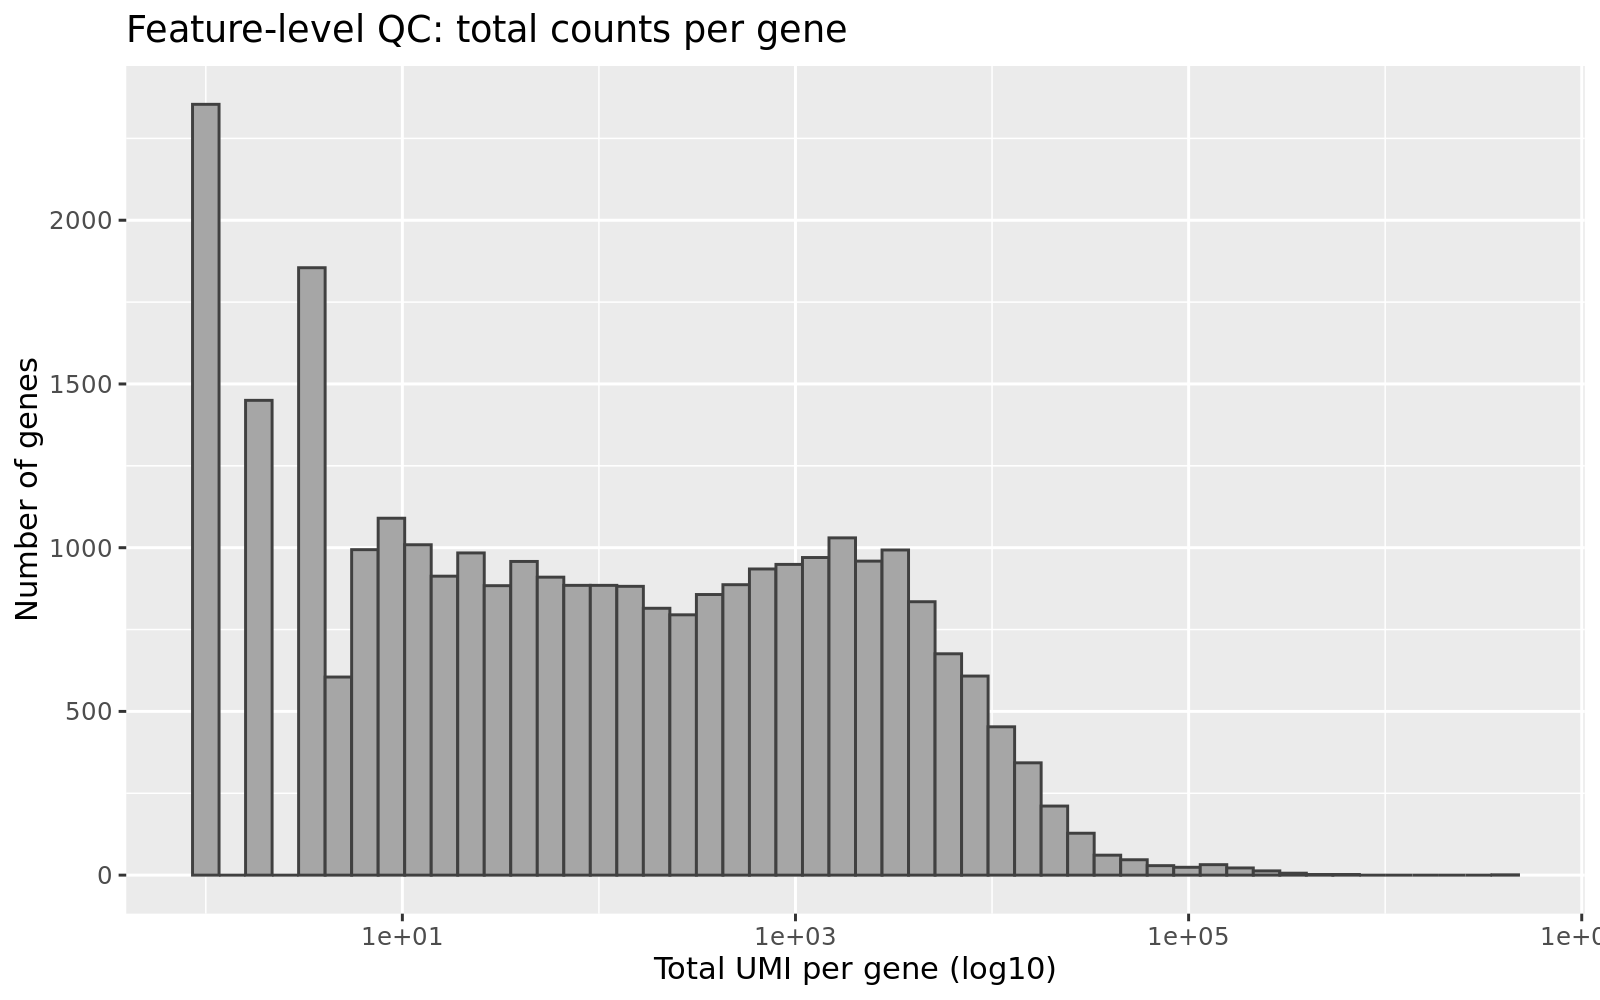

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
p6

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


Warning message:
“Removed 14533 rows containing non-finite outside the scale range
(`stat_bin()`).”


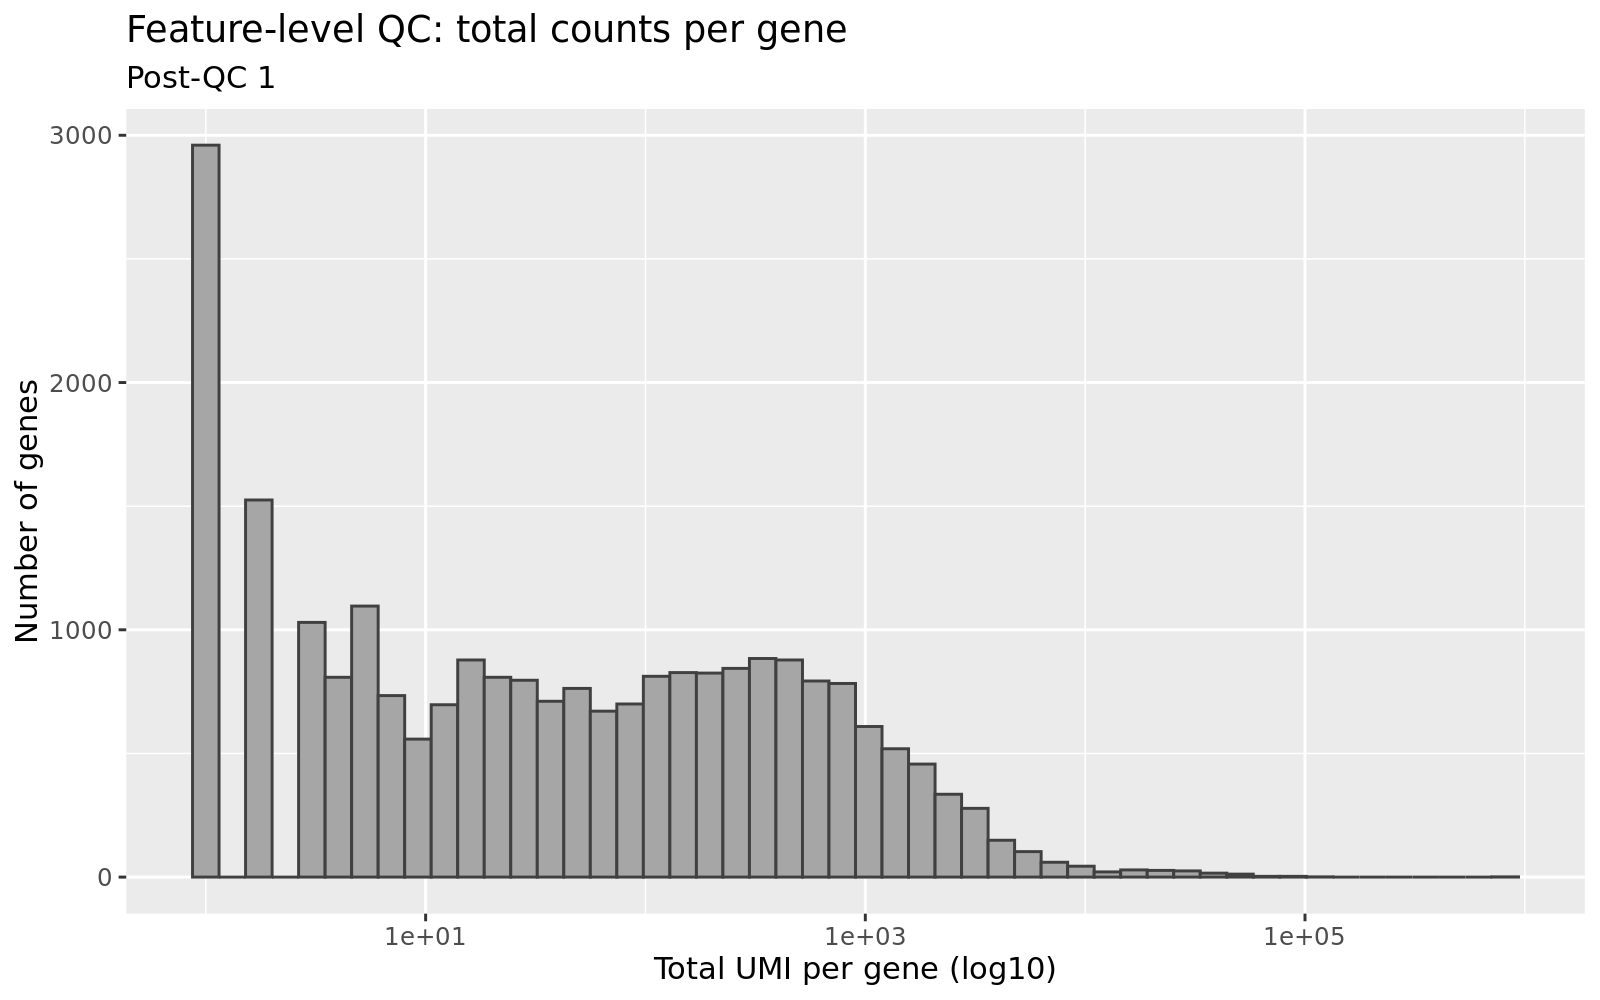

In [105]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
p7

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 9620 rows containing non-finite outside the scale range (`stat_bin()`).”


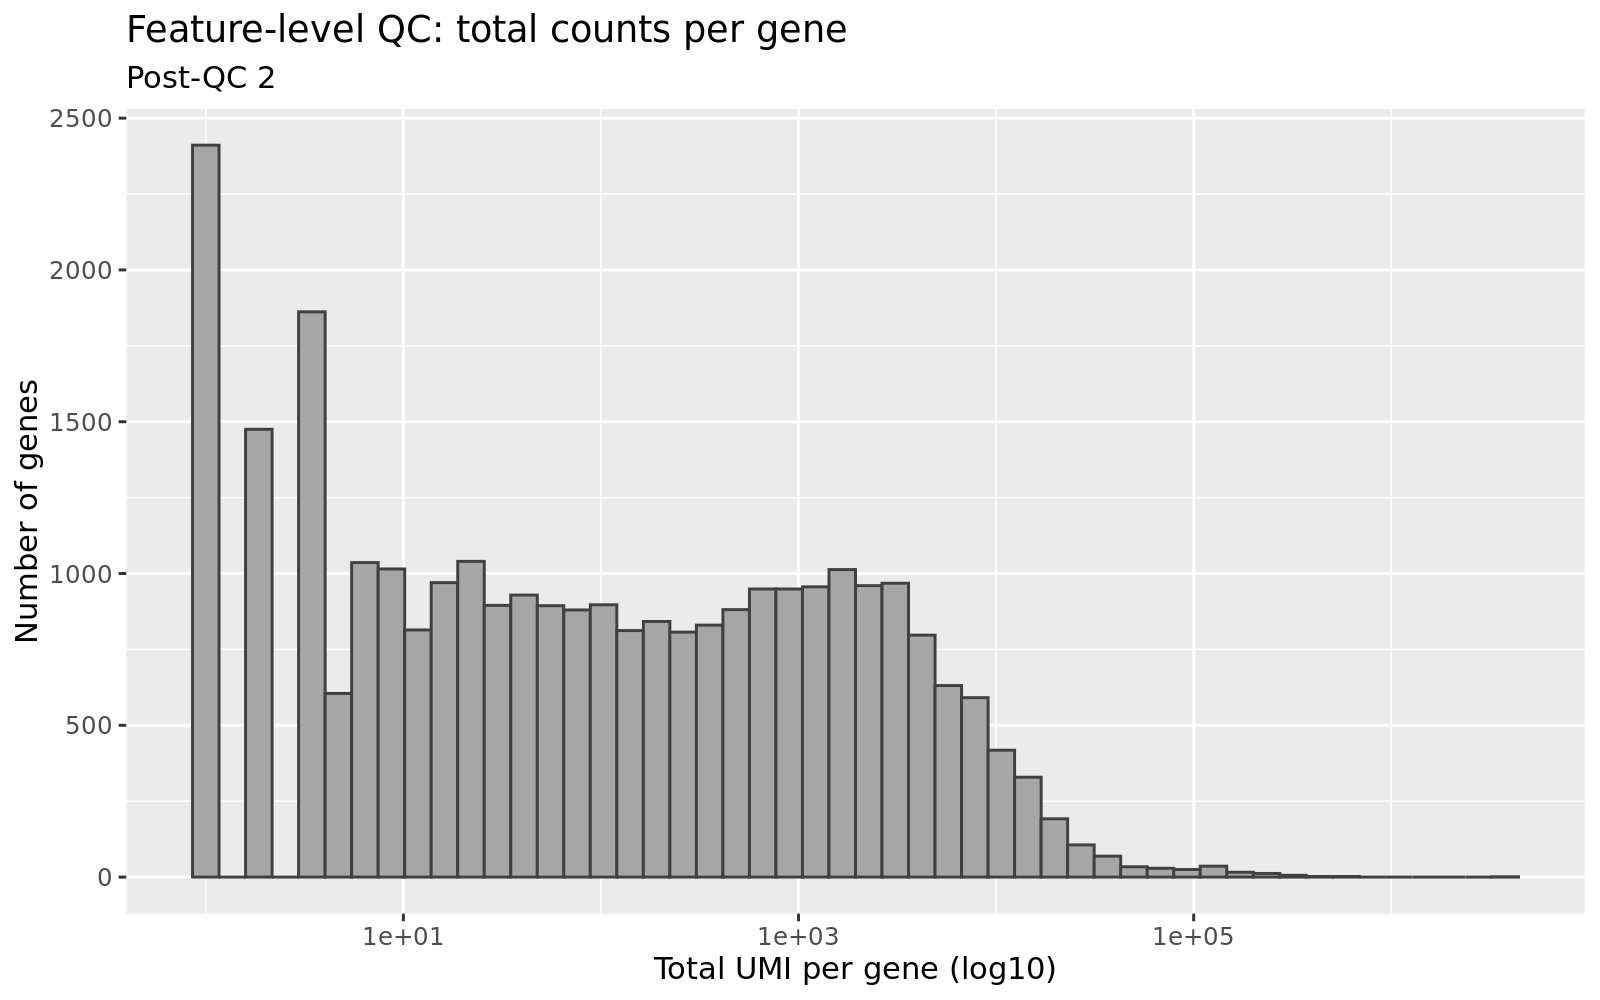

In [104]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
p8